# 技术指标计算 Notebook —— 兆易创新 (603986)

## 目标
- 从零实现 5 个经典技术指标（不依赖 TA-Lib 等现成库）
- 每个指标分步展示计算过程
- 配套可视化图表
- 综合信号分析：寻找多指标共振的买卖时点

## 指标清单
| 指标 | 类型 | 核心参数 |
|------|------|----------|
| RSI  | 动量/超买超卖 | N=14 |
| MACD | 趋势/动能   | 12 / 26 / 9 |
| 布林带 | 波动率/通道 | 20日均线 + 2倍标准差 |
| ATR  | 波动率       | N=14 |
| KDJ  | 动量/随机   | (9, 3, 3) |

## 0. 环境准备与数据加载

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from matplotlib.patches import Rectangle
import warnings
from matplotlib.dates import DateFormatter
from matplotlib.ticker import ScalarFormatter
warnings.filterwarnings('ignore')

# 中文显示配置（Windows）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

print('pandas :', pd.__version__)
print('numpy  :', np.__version__)
print('环境准备完成')

pandas : 3.0.3
numpy  : 2.5.0
环境准备完成


In [50]:
# 读取数据
df = pd.read_csv('兆易创新_近一年交易数据.csv')
df.head()

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,603986.SH,20260702,721.0,731.99,694.81,694.81,772.01,-77.20,-9.9999,452436.41,3.212068e+07
1,603986.SH,20260701,803.0,843.38,753.00,772.01,815.00,-42.99,-5.2748,539702.17,4.320285e+07
2,603986.SH,20260630,810.0,833.00,781.11,815.00,840.00,-25.00,-2.9762,449646.79,3.639935e+07
3,603986.SH,20260629,779.0,846.66,750.00,840.00,770.00,70.00,9.0909,541208.83,4.314993e+07
4,603986.SH,20260626,753.0,779.00,732.52,770.00,775.21,-5.21,-0.6721,493925.62,3.741830e+07


In [51]:
# 数据预处理
print('原始数据形状：', df.shape)
print('\n原始排序（前5行）：')
print(df['trade_date'].head().tolist())
print('\n原始排序（后5行）：')
print(df['trade_date'].tail().tolist())

# CSV 是降序（最新在前），需要转为升序
df = df.sort_values('trade_date').reset_index(drop=True)

print('\n>>> 排序后（前5行）：')
print(df['trade_date'].head().tolist())
print('\n>>> 排序后（后5行）：')
print(df['trade_date'].tail().tolist())

# 检查缺失值
print('\n>>> 缺失值统计：')
print(df.isnull().sum())

# 将 trade_date 转为 datetime 类型（确保 x 轴正确显示为日期）
df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
print(f'\n>>> 日期范围：{df["trade_date"].min().date()}  ~  {df["trade_date"].max().date()}')

原始数据形状： (243, 11)

原始排序（前5行）：
[20260702, 20260701, 20260630, 20260629, 20260626]

原始排序（后5行）：
[20250708, 20250707, 20250704, 20250703, 20250702]

>>> 排序后（前5行）：
[20250702, 20250703, 20250704, 20250707, 20250708]

>>> 排序后（后5行）：
[20260626, 20260629, 20260630, 20260701, 20260702]

>>> 缺失值统计：
ts_code       0
trade_date    0
open          0
high          0
low           0
close         0
pre_close     0
change        0
pct_chg       0
vol           0
amount        0
dtype: int64

>>> 日期范围：2025-07-02  ~  2026-07-02


数据形状： (243, 11)

列名： ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 'pre_close', 'change', 'pct_chg', 'vol', 'amount']

数据统计：


,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
count,243,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,2.430000e+02
mean,2025-12-30 01:17:02.222222,266.787037,275.887942,260.067778,268.770288,266.416872,2.353416,0.805735,374965.936996,1.093257e+07
min,2025-07-02 00:00:00,114.050000,116.400000,113.820000,114.240000,114.240000,-77.200000,-10.000600,111583.310000,1.322615e+06
25%,2025-09-24 12:00:00,191.450000,198.485000,186.710000,190.910000,190.750000,-5.160000,-2.252050,254798.800000,5.591047e+06
50%,2025-12-26 00:00:00,231.000000,235.680000,222.830000,232.000000,230.100000,0.900000,0.423000,367244.060000,8.650850e+06
75%,2026-04-01 12:00:00,300.400000,309.645000,292.910000,302.355000,300.735000,7.110000,3.261000,464717.580000,1.253389e+07
max,2026-07-02 00:00:00,810.000000,846.660000,781.110000,840.000000,840.000000,70.120000,10.002900,858971.490000,4.320285e+07
std,NaN,136.022188,143.273249,130.988932,139.297730,136.871198,16.347900,4.334635,153897.500160,8.729105e+06


findfont: Failed to find font weight 600, now using 700.


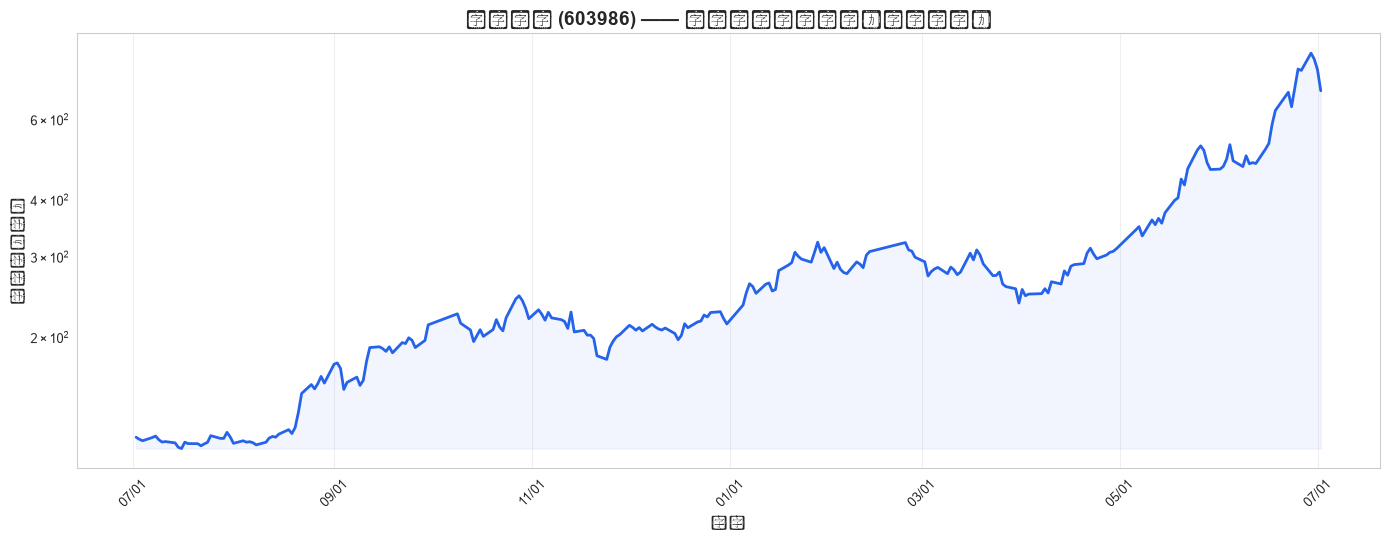

💡 使用对数坐标后，相同涨幅在图上显示的高度一致。
   价格范围：¥114.2  ~  ¥840.0


In [52]:
# 数据预览
print('数据形状：', df.shape)
print('\n列名：', df.columns.tolist())
print('\n数据统计：')
display(df.describe())

# 绘制原始收盘价走势（使用对数坐标）
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(df['trade_date'], df['close'], color='#2563EB', linewidth=2, label='收盘价')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.fill_between(df['trade_date'], df['close'].min(), df['close'], alpha=0.06, color='#2563EB')
ax.set_title('兆易创新 (603986) —— 近一年收盘价走势（对数坐标）', fontsize=14, fontweight='600')
ax.set_xlabel('日期')
ax.set_ylabel('收盘价（元）')
ax.tick_params(axis='x', rotation=45)
ax.xaxis.set_major_formatter(DateFormatter('%m/%d'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('💡 使用对数坐标后，相同涨幅在图上显示的高度一致。')
print(f'   价格范围：¥{df["close"].min():.1f}  ~  ¥{df["close"].max():.1f}')

## 绘图样式配置

统一设置全局样式，后续所有图表将共享：  
- **对数坐标**：价格图使用对数刻度，消除价格量级差异  
- **日期格式**：x 轴自动格式化为月/日  
- **专业配色**：统一的颜色方案和布局

In [53]:
from matplotlib.dates import DateFormatter
from matplotlib.ticker import ScalarFormatter

# 全局样式
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATE_FMT = DateFormatter('%m/%d')  # x 轴日期格式

def setup_price_axis(ax, title=None):
    """为价格子图设置对数坐标和日期格式"""
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_formatter(DATE_FMT)
    ax.grid(alpha=0.3)
    if title:
        ax.set_title(title, fontsize=13, fontweight='600', pad=12)

def setup_indicator_axis(ax, ylabel):
    """为指标子图设置日期格式"""
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_formatter(DATE_FMT)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(alpha=0.3)

print('✅ 全局样式配置完成')
print('   - 价格图：对数坐标')
print('   - 日期格式：月/日')
print('   - 专业配色方案')

✅ 全局样式配置完成
   - 价格图：对数坐标
   - 日期格式：月/日
   - 专业配色方案


---
## 一、RSI 相对强弱指数

**原理**：比较过去 N 日上涨幅度和下跌幅度的比值，判断超买/超卖状态。

**公式**：
- $\Delta = C_t - C_{{t-1}}$  
- $gain = \Delta$ （若 $\Delta > 0$，否则为 0）  
- $loss = -\Delta$ （若 $\Delta < 0$，否则为 0）  
- $avg\_gain = gain$ 的 N 日平滑平均  
- $avg\_loss = loss$ 的 N 日平滑平均  
- $RS = avg\_gain / avg\_loss$  
- $RSI = 100 - \frac{100}{1 + RS}$  

**参数**：N = 14（常用）  
**信号**：RSI > 70 超买（警惕回调）；RSI < 30 超卖（警惕反弹）

### Step 1：计算 delta、gain、loss

In [54]:
N = 14   # RSI 参数

# 计算价格变化
df['delta'] = df['close'].diff()

# gain：上涨部分（跌的日子为 0）
df['gain'] = df['delta'].where(df['delta'] > 0, 0.0)

# loss：下跌部分（涨的日子为 0，存为正值）
df['loss'] = -df['delta'].where(df['delta'] < 0, 0.0)

rsi_debug = df[['trade_date', 'close', 'delta', 'gain', 'loss']].head(20)
rsi_debug

,trade_date,close,delta,gain,loss
0,2025-07-02,120.98,NaN,0.00,-0.00
1,2025-07-03,119.72,-1.26,0.00,1.26
2,2025-07-04,118.85,-0.87,0.00,0.87
3,2025-07-07,120.81,1.96,1.96,-0.00
4,2025-07-08,121.71,0.90,0.90,-0.00
5,2025-07-09,119.47,-2.24,0.00,2.24
6,2025-07-10,118.06,-1.41,0.00,1.41
7,2025-07-11,118.36,0.30,0.30,-0.00
8,2025-07-14,117.59,-0.77,0.00,0.77
9,2025-07-15,115.00,-2.59,0.00,2.59


### Step 2：计算 avg_gain 和 avg_loss（平滑处理）

> RSI 使用的是**平滑平均**（Wilder 平滑法），而非简单移动平均。  
> 第 N 日之后的每个值 = 前一日平滑值 × (N-1)/N + 当日 gain/loss × 1/N

In [55]:
# 方法一：用 ewm 实现 Wilder 平滑（推荐）
alpha = 1 / N
df['avg_gain'] = df['gain'].ewm(alpha=alpha, adjust=False).mean()
df['avg_loss'] = df['loss'].ewm(alpha=alpha, adjust=False).mean()

# 验证：手动计算前 N+2 行
print('=== 手动验证 Wilder 平滑法（前20行）===')
for i in range(N+5):
    if i < N:
        print(f'Row {i}: avg_gain={df["avg_gain"].iloc[i]:.4f}  (前{N}行取简单平均)')
    else:
        prev = df['avg_gain'].iloc[i-1]
        cur_gain = df['gain'].iloc[i]
        manual = prev * (N-1)/N + cur_gain * 1/N
        print(f'Row {i}: ewm={df["avg_gain"].iloc[i]:.4f}  manual={manual:.4f}')
    if i == N+2: break

display(df[['trade_date', 'gain', 'loss', 'avg_gain', 'avg_loss']].head(20))

=== 手动验证 Wilder 平滑法（前20行）===
Row 0: avg_gain=0.0000  (前14行取简单平均)
Row 1: avg_gain=0.0000  (前14行取简单平均)
Row 2: avg_gain=0.0000  (前14行取简单平均)
Row 3: avg_gain=0.1400  (前14行取简单平均)
Row 4: avg_gain=0.1943  (前14行取简单平均)
Row 5: avg_gain=0.1804  (前14行取简单平均)
Row 6: avg_gain=0.1675  (前14行取简单平均)
Row 7: avg_gain=0.1770  (前14行取简单平均)
Row 8: avg_gain=0.1643  (前14行取简单平均)
Row 9: avg_gain=0.1526  (前14行取简单平均)
Row 10: avg_gain=0.1417  (前14行取简单平均)
Row 11: avg_gain=0.3994  (前14行取简单平均)
Row 12: avg_gain=0.3709  (前14行取简单平均)
Row 13: avg_gain=0.3444  (前14行取简单平均)
Row 14: ewm=0.3198  manual=0.3198
Row 15: ewm=0.3770  manual=0.3770
Row 16: ewm=0.4143  manual=0.4143


,trade_date,gain,loss,avg_gain,avg_loss
0,2025-07-02,0.00,-0.00,0.000000,-0.000000
1,2025-07-03,0.00,1.26,0.000000,0.090000
2,2025-07-04,0.00,0.87,0.000000,0.145714
3,2025-07-07,1.96,-0.00,0.140000,0.135306
4,2025-07-08,0.90,-0.00,0.194286,0.125641
5,2025-07-09,0.00,2.24,0.180408,0.276667
6,2025-07-10,0.00,1.41,0.167522,0.357619
7,2025-07-11,0.30,-0.00,0.176985,0.332075
8,2025-07-14,0.00,0.77,0.164343,0.363355
9,2025-07-15,0.00,2.59,0.152604,0.522402


### Step 3：计算 RSI 并绘图

In [56]:
# 计算 RS 和 RSI
df['RS'] = df['avg_gain'] / df['avg_loss']
df['RSI_14'] = 100 - (100 / (1 + df['RS']))

# 查看结果（跳过前14行 NaN）
display(df[['trade_date', 'close', 'RS', 'RSI_14']].iloc[14:30])

,trade_date,close,RS,RSI_14
14,2025-07-22,115.87,0.587879,37.022918
15,2025-07-23,116.99,0.746247,42.734325
16,2025-07-24,117.89,0.883296,46.901590
17,2025-07-25,121.94,1.547455,60.745140
18,2025-07-28,120.26,1.193383,54.408335
19,2025-07-29,120.28,1.196317,54.469228
20,2025-07-30,123.99,1.782330,64.058899
21,2025-07-31,121.13,1.199010,54.524989
22,2025-08-01,117.31,0.815231,44.910585
23,2025-08-04,118.84,0.953292,48.804374


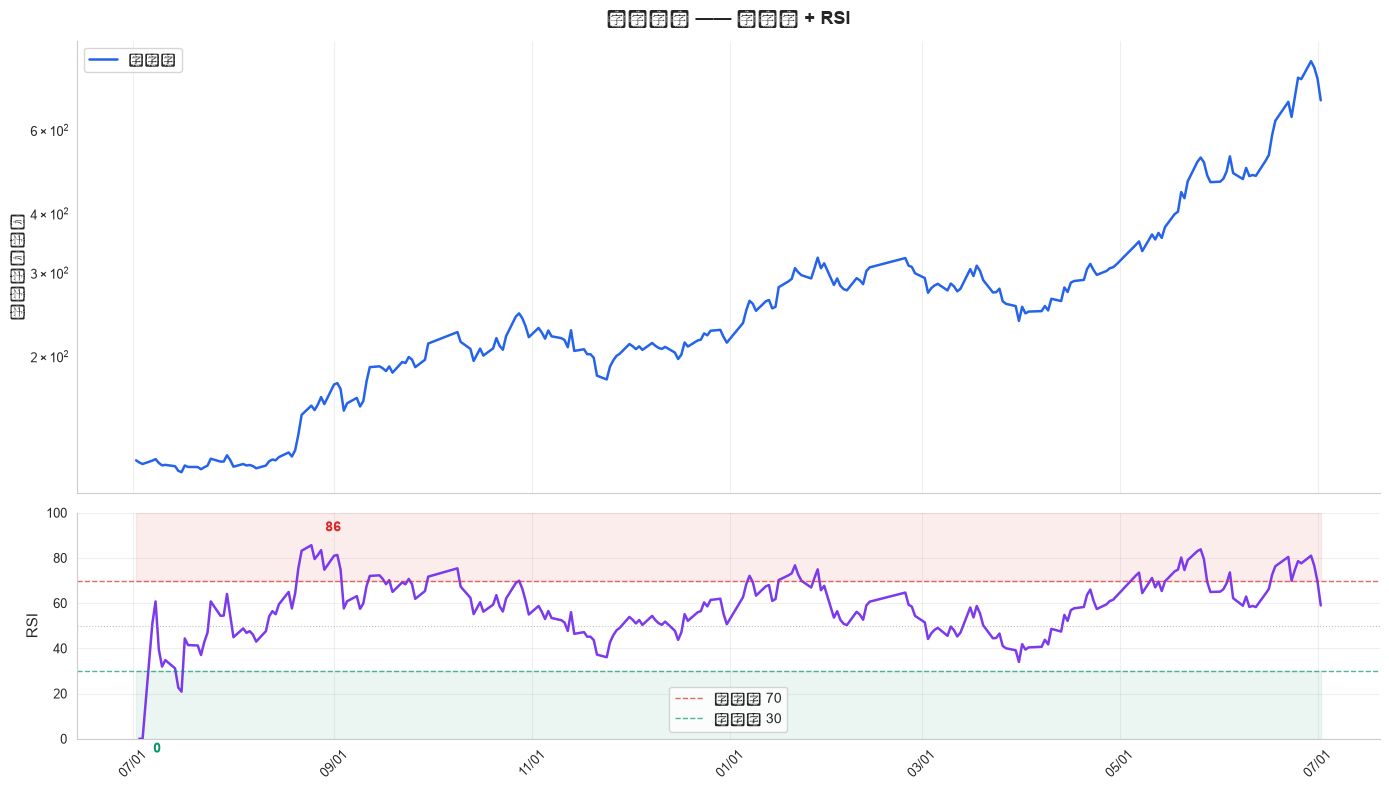

RSI > 70（超买）天数：45
RSI < 30（超卖）天数：4


In [57]:
# 绘制 RSI 图（对数坐标 + 专业样式）
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})

# 上图：收盘价（对数坐标）
ax1.plot(df['trade_date'], df['close'], color='#2563EB', linewidth=1.8, label='收盘价')
setup_price_axis(ax1, '兆易创新 —— 收盘价 + RSI')
ax1.set_ylabel('收盘价（元）', fontsize=11)
ax1.legend(fontsize=10)

# 下图：RSI
ax2.plot(df['trade_date'], df['RSI_14'], color='#7C3AED', linewidth=1.8)
ax2.axhline(70, color='#DC2626', linestyle='--', linewidth=1, alpha=0.7, label='超买线 70')
ax2.axhline(30, color='#059669', linestyle='--', linewidth=1, alpha=0.7, label='超卖线 30')
ax2.axhline(50, color='#888780', linestyle=':', linewidth=0.8, alpha=0.5)
ax2.fill_between(df['trade_date'], 70, 100, alpha=0.08, color='#DC2626')
ax2.fill_between(df['trade_date'], 0, 30, alpha=0.08, color='#059669')
setup_indicator_axis(ax2, 'RSI')
ax2.set_ylim(0, 100)
ax2.legend(fontsize=10)

# 标注极端 RSI 值
rsi_max_idx = df['RSI_14'].idxmax()
rsi_min_idx = df['RSI_14'].idxmin()
if pd.notna(rsi_max_idx):
    ax2.annotate(f'{df["RSI_14"].iloc[rsi_max_idx]:.0f}',
                xy=(df['trade_date'].iloc[rsi_max_idx], df['RSI_14'].iloc[rsi_max_idx]),
                xytext=(10, 10), textcoords='offset points',
                color='#DC2626', fontweight='bold')
if pd.notna(rsi_min_idx):
    ax2.annotate(f'{df["RSI_14"].iloc[rsi_min_idx]:.0f}',
                xy=(df['trade_date'].iloc[rsi_min_idx], df['RSI_14'].iloc[rsi_min_idx]),
                xytext=(10, -10), textcoords='offset points',
                color='#059669', fontweight='bold')

plt.tight_layout()
plt.show()

# 统计 RSI 信号
overbought = (df['RSI_14'] > 70).sum()
oversold = (df['RSI_14'] < 30).sum()
print(f'RSI > 70（超买）天数：{overbought}')
print(f'RSI < 30（超卖）天数：{oversold}')

---
## 二、MACD 指数平滑异同移动平均线

**原理**：用两条指数移动平均线（EMA）之间的距离变化，捕捉趋势动能的强弱和转折。

**公式**：
- $EMA_{{fast}} = close$ 的 12 日 EMA  
- $EMA_{{slow}} = close$ 的 26 日 EMA  
- $DIF = EMA_{{fast}} - EMA_{{slow}}$  
- $DEA = DIF$ 的 9 日 EMA（信号线）  
- $MACD\_hist = (DIF - DEA) \times 2$（A股常用 ×2 放大）

**信号**：  
- **金叉**：DIF 由下向上穿越 DEA → 买入信号  
- **死叉**：DIF 由上向下穿越 DEA → 卖出信号  
- **柱状图由负转正** → 多头占优；**由正转负** → 空头占优

### Step 1：手动实现 EMA 函数并验证

In [58]:
def calc_ema(series, span):
    """
    手动实现 EMA（指数移动平均）
    EMA_t = alpha * price_t + (1 - alpha) * EMA_{t-1}
    alpha = 2 / (span + 1)
    """
    alpha = 2 / (span + 1)
    ema = series.copy()
    ema.iloc[0] = series.iloc[0]  # 第一天用收盘价本身
    for i in range(1, len(series)):
        ema.iloc[i] = alpha * series.iloc[i] + (1 - alpha) * ema.iloc[i-1]
    return ema

# 用自定义函数计算 EMA
df['EMA12_manual'] = calc_ema(df['close'], 12)
df['EMA26_manual'] = calc_ema(df['close'], 26)

# 用 pandas ewm() 计算（作为基准对比）
df['EMA12_pandas'] = df['close'].ewm(span=12, adjust=False).mean()
df['EMA26_pandas'] = df['close'].ewm(span=26, adjust=False).mean()

# 对比前 20 行（看收敛过程）
compare = df[['trade_date', 'close', 'EMA12_manual', 'EMA12_pandas', 'EMA26_manual', 'EMA26_pandas']].head(20).copy()
display(compare)

# 检查差值（应该接近 0）
diff12 = (df['EMA12_manual'] - df['EMA12_pandas']).abs().max()
diff26 = (df['EMA26_manual'] - df['EMA26_pandas']).abs().max()
print(f'EMA12 最大差值：{diff12:.10f}')
print(f'EMA26 最大差值：{diff26:.10f}')
print('✅ 手动实现与 pandas ewm() 结果一致！' if diff12 < 1e-6 else '❌ 有差异，请检查代码')

,trade_date,close,EMA12_manual,EMA12_pandas,EMA26_manual,EMA26_pandas
0,2025-07-02,120.98,120.980000,120.980000,120.980000,120.980000
1,2025-07-03,119.72,120.786154,120.786154,120.886667,120.886667
2,2025-07-04,118.85,120.488284,120.488284,120.735802,120.735802
3,2025-07-07,120.81,120.537779,120.537779,120.741299,120.741299
4,2025-07-08,121.71,120.718121,120.718121,120.813054,120.813054
5,2025-07-09,119.47,120.526102,120.526102,120.713569,120.713569
6,2025-07-10,118.06,120.146702,120.146702,120.517008,120.517008
7,2025-07-11,118.36,119.871824,119.871824,120.357230,120.357230
8,2025-07-14,117.59,119.520775,119.520775,120.152250,120.152250
9,2025-07-15,115.00,118.825271,118.825271,119.770602,119.770602


EMA12 最大差值：0.0000000000
EMA26 最大差值：0.0000000000
✅ 手动实现与 pandas ewm() 结果一致！


### Step 2：计算 DIF、DEA、MACD 柱状图

In [59]:
# 使用 pandas ewm() 计算（与手动结果一致，代码更简洁）
df['EMA12'] = df['close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['close'].ewm(span=26, adjust=False).mean()

# DIF = 快线 - 慢线
df['DIF'] = df['EMA12'] - df['EMA26']

# DEA = DIF 的 9 日 EMA（信号线）
df['DEA'] = df['DIF'].ewm(span=9, adjust=False).mean()

# MACD 柱状图（A股惯例 ×2 放大）
df['MACD_hist'] = (df['DIF'] - df['DEA']) * 2

display(df[['trade_date', 'close', 'EMA12', 'EMA26', 'DIF', 'DEA', 'MACD_hist']].head(30))

,trade_date,close,EMA12,EMA26,DIF,DEA,MACD_hist
0,2025-07-02,120.98,120.980000,120.980000,0.000000,0.000000,0.000000
1,2025-07-03,119.72,120.786154,120.886667,-0.100513,-0.020103,-0.160821
2,2025-07-04,118.85,120.488284,120.735802,-0.247518,-0.065586,-0.363865
3,2025-07-07,120.81,120.537779,120.741299,-0.203520,-0.093173,-0.220694
4,2025-07-08,121.71,120.718121,120.813054,-0.094934,-0.093525,-0.002818
5,2025-07-09,119.47,120.526102,120.713569,-0.187467,-0.112313,-0.150307
6,2025-07-10,118.06,120.146702,120.517008,-0.370306,-0.163912,-0.412789
7,2025-07-11,118.36,119.871824,120.357230,-0.485405,-0.228211,-0.514389
8,2025-07-14,117.59,119.520775,120.152250,-0.631475,-0.308863,-0.645223
9,2025-07-15,115.00,118.825271,119.770602,-0.945331,-0.436157,-1.018348


### Step 3：绘制 MACD 图 + 标注金叉/死叉

金叉次数：10，死叉次数：9

金叉日期（前10个）：
  2025-07-25 00:00:00  DIF=-0.605
  2025-08-12 00:00:00  DIF=-0.215
  2025-09-11 00:00:00  DIF=10.798
  2025-09-30 00:00:00  DIF=14.150
  2025-10-27 00:00:00  DIF=12.718
  2025-12-02 00:00:00  DIF=-2.141
  2025-12-18 00:00:00  DIF=-0.090
  2026-03-18 00:00:00  DIF=3.202
  2026-04-13 00:00:00  DIF=-7.880
  2026-06-17 00:00:00  DIF=39.432

死叉日期（前10个）：
  2025-08-07 00:00:00  DIF=-0.232
  2025-09-09 00:00:00  DIF=10.528
  2025-09-26 00:00:00  DIF=13.471
  2025-10-14 00:00:00  DIF=13.704
  2025-11-03 00:00:00  DIF=12.899
  2025-12-16 00:00:00  DIF=-0.629
  2026-02-02 00:00:00  DIF=19.972
  2026-03-23 00:00:00  DIF=1.447
  2026-06-05 00:00:00  DIF=45.200


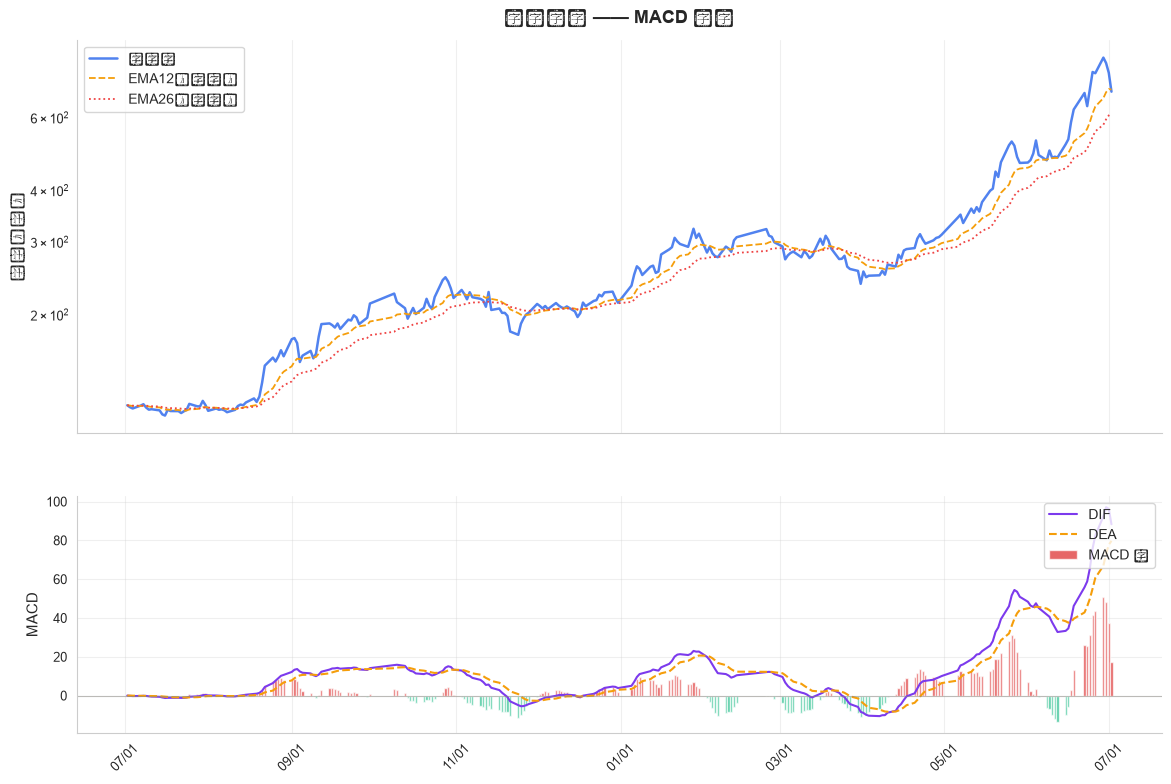

In [60]:
from matplotlib.patches import Patch

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1.2]})

# ===== 上图：价格 + EMA（对数坐标） =====
ax1.plot(df['trade_date'], df['close'], color='#2563EB', linewidth=1.8, label='收盘价', alpha=0.8)
ax1.plot(df['trade_date'], df['EMA12'], color='#F59E0B', linewidth=1.3, label='EMA12（快线）', linestyle='--')
ax1.plot(df['trade_date'], df['EMA26'], color='#EF4444', linewidth=1.3, label='EMA26（慢线）', linestyle=':')
setup_price_axis(ax1, '兆易创新 —— MACD 指标')
ax1.set_ylabel('价格（元）', fontsize=11)
ax1.legend(fontsize=10)

# ===== 下图：MACD =====
# 柱状图颜色（涨=红，跌=绿，A股惯例）
colors = ['#DC2626' if v >= 0 else '#10B981' for v in df['MACD_hist']]
ax2.bar(df['trade_date'], df['MACD_hist'], color=colors, alpha=0.7, width=0.8, label='MACD 柱')

# DIF 和 DEA 线
ax2.plot(df['trade_date'], df['DIF'], color='#7C3AED', linewidth=1.5, label='DIF')
ax2.plot(df['trade_date'], df['DEA'], color='#F59E0B', linewidth=1.5, label='DEA', linestyle='--')
ax2.axhline(0, color='#888780', linewidth=0.8, alpha=0.5)
setup_indicator_axis(ax2, 'MACD')
ax2.legend(fontsize=10, loc='upper right')

# 找出金叉和死叉位置
golden_cross = []
death_cross = []
for i in range(1, len(df)):
    if df['DIF'].iloc[i-1] < df['DEA'].iloc[i-1] and df['DIF'].iloc[i] > df['DEA'].iloc[i]:
        golden_cross.append(i)
    elif df['DIF'].iloc[i-1] > df['DEA'].iloc[i-1] and df['DIF'].iloc[i] < df['DEA'].iloc[i]:
        death_cross.append(i)

print(f'金叉次数：{len(golden_cross)}，死叉次数：{len(death_cross)}')
print('\n金叉日期（前10个）：')
for idx in golden_cross[:10]:
    print(f'  {df["trade_date"].iloc[idx]}  DIF={df["DIF"].iloc[idx]:.3f}')
print('\n死叉日期（前10个）：')
for idx in death_cross[:10]:
    print(f'  {df["trade_date"].iloc[idx]}  DIF={df["DIF"].iloc[idx]:.3f}')

---
## 三、布林带（Bollinger Bands）

**原理**：假设价格围绕均值呈正态分布，用「均线 ± N 倍标准差」构建动态通道，衡量价格相对位置和波动范围。

**公式**：
- $MB = close$ 的 20 日简单移动平均  
- $UP = MB + 2 \times \sigma_{{20}}$  
- $DN = MB - 2 \times \sigma_{{20}}$  
- $Bandwidth = \frac{UP - DN}{MB}$（带宽，衡量波动大小）  
- $\%B = \frac{close - DN}{UP - DN}$（价格在带内的相对位置）

**信号**：  
- 价格触碰/突破上轨 → 超买，警惕回调  
- 价格触碰/突破下轨 → 超卖，警惕反弹  
- 带宽收窄（挤压）→ 即将出现大幅波动（方向不明）

### Step 1：计算中轨、上轨、下轨

In [61]:
N_bb = 20
K_bb = 2   # 标准差倍数

# 中轨 = 20 日简单移动平均
df['BB_middle'] = df['close'].rolling(window=N_bb).mean()

# 标准差
df['BB_std'] = df['close'].rolling(window=N_bb).std()

# 上轨和下轨
df['BB_upper'] = df['BB_middle'] + K_bb * df['BB_std']
df['BB_lower'] = df['BB_middle'] - K_bb * df['BB_std']

# 计算 %B 和带宽
df['BB_percentB'] = (df['close'] - df['BB_lower']) / (df['BB_upper'] - df['BB_lower'])
df['BB_bandwidth'] = (df['BB_upper'] - df['BB_lower']) / df['BB_middle']

display(df[['trade_date', 'close', 'BB_middle', 'BB_upper', 'BB_lower', 'BB_percentB', 'BB_bandwidth']].iloc[19:35])

,trade_date,close,BB_middle,BB_upper,BB_lower,BB_percentB,BB_bandwidth
19,2025-07-29,120.28,118.5140,122.804353,114.223647,0.705811,0.072402
20,2025-07-30,123.99,118.6645,123.496113,113.832887,1.051110,0.081433
21,2025-07-31,121.13,118.7350,123.671470,113.798530,0.742582,0.083151
22,2025-08-01,117.31,118.6580,123.634795,113.681205,0.364571,0.083885
23,2025-08-04,118.84,118.5595,123.433886,113.685114,0.528773,0.082227
24,2025-08-05,118.00,118.3740,123.020617,113.727383,0.459756,0.078507
25,2025-08-06,118.28,118.3145,122.932412,113.696588,0.496265,0.078062
26,2025-08-07,117.67,118.2950,122.920724,113.669276,0.432443,0.078207
27,2025-08-08,116.40,118.1970,122.899340,113.494660,0.308925,0.079568
28,2025-08-11,117.95,118.2150,122.910308,113.519692,0.471780,0.079437


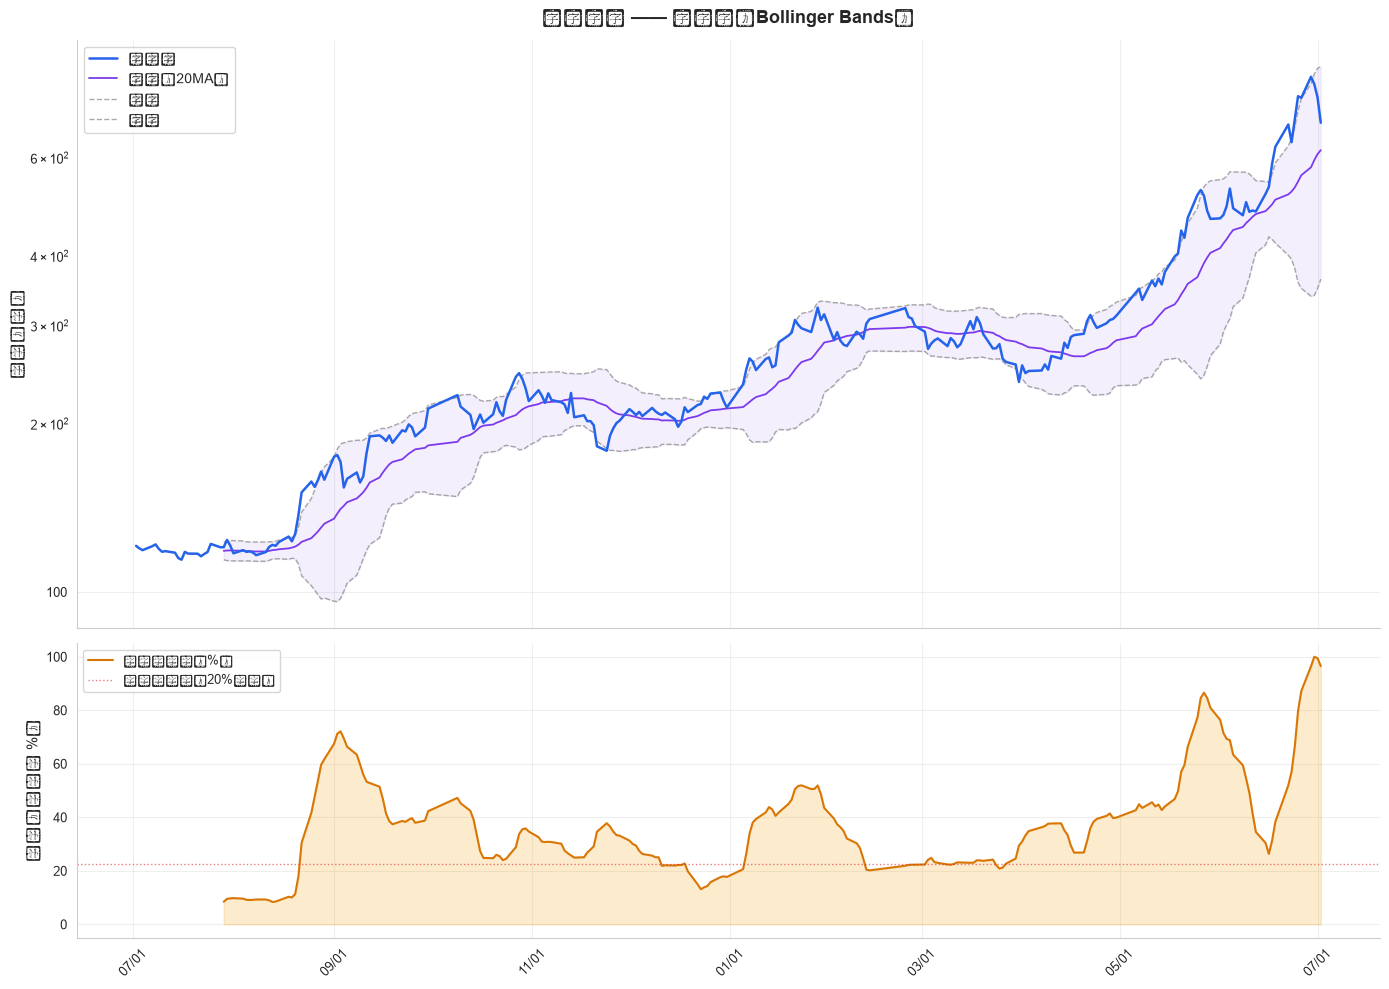

价格 >= 上轨的天数：37
价格 <= 下轨的天数：3

触碰上轨日期（前10个）： [Timestamp('2025-07-30 00:00:00'), Timestamp('2025-08-18 00:00:00'), Timestamp('2025-08-20 00:00:00'), Timestamp('2025-08-21 00:00:00'), Timestamp('2025-08-22 00:00:00'), Timestamp('2025-08-25 00:00:00'), Timestamp('2025-08-26 00:00:00'), Timestamp('2025-08-27 00:00:00'), Timestamp('2025-08-28 00:00:00'), Timestamp('2025-09-01 00:00:00')]
触碰下轨日期（前10个）： [Timestamp('2025-11-21 00:00:00'), Timestamp('2025-11-24 00:00:00'), Timestamp('2026-03-31 00:00:00')]


In [62]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})

# ===== 上图：价格 + 布林带（对数坐标） =====
ax1.plot(df['trade_date'], df['close'], color='#2563EB', linewidth=1.8, label='收盘价', zorder=5)
ax1.plot(df['trade_date'], df['BB_middle'], color='#7C3AED', linewidth=1.3, label='中轨（20MA）', zorder=4)
ax1.plot(df['trade_date'], df['BB_upper'], color='#888780', linewidth=1, linestyle='--', alpha=0.7, label='上轨', zorder=3)
ax1.plot(df['trade_date'], df['BB_lower'], color='#888780', linewidth=1, linestyle='--', alpha=0.7, label='下轨', zorder=3)

# 带状区域填充
ax1.fill_between(df['trade_date'], df['BB_lower'], df['BB_upper'], alpha=0.08, color='#7C3AED', zorder=1)
setup_price_axis(ax1, '兆易创新 —— 布林带（Bollinger Bands）')
ax1.set_ylabel('价格（元）', fontsize=11)
ax1.legend(fontsize=10)

# ===== 下图：带宽 =====
bandwidth_norm = df['BB_bandwidth'] / df['BB_bandwidth'].max() * 100
ax2.fill_between(df['trade_date'], 0, bandwidth_norm, alpha=0.2, color='#F59E0B')
ax2.plot(df['trade_date'], bandwidth_norm, color='#D97706', linewidth=1.5, label='标准化带宽（%）')
ax2.axhline(bandwidth_norm.quantile(0.2), color='#DC2626', linestyle=':', linewidth=1, alpha=0.6, label='低波动阈值（20%分位）')
setup_indicator_axis(ax2, '带宽（标准化 %）')
ax2.legend(fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 标注触碰轨道的日期
touch_upper = df[df['close'] >= df['BB_upper']]
touch_lower = df[df['close'] <= df['BB_lower']]
print(f'价格 >= 上轨的天数：{len(touch_upper)}')
print(f'价格 <= 下轨的天数：{len(touch_lower)}')
if len(touch_upper) > 0:
    print('\n触碰上轨日期（前10个）：', touch_upper['trade_date'].head(10).tolist())
if len(touch_lower) > 0:
    print('触碰下轨日期（前10个）：', touch_lower['trade_date'].head(10).tolist())

---
## 四、ATR 平均真实波幅（Average True Range）

**原理**：真实的每日波动幅度不只是 H - L，还要考虑跳空缺口（前日收盘与今日开盘之间的缺口）。ATR 取三者最大值，再取 N 日平滑平均。

**公式**：
- $TR = \max(H - L,\ |H - C_{{prev}}|,\ |L - C_{{prev}}|)$  
- $ATR = TR$ 的 Wilder 平滑平均（N=14）

> ⚠️ ATR **不预测方向**，只衡量波动大小。  
> 高 ATR → 波动大，风险高，应降低仓位  
> 低 ATR → 波动小，可能即将变盘（配合布林带挤压信号）

**止损应用**：止损距离 = 入场价 ± N × ATR（常用 N=2）

### Step 1：计算真实波幅 TR

In [63]:
# 前一日收盘价（向下错位）
df['close_prev'] = df['close'].shift(1)

# 三个候选值
tr1 = df['high'] - df['low']                          # 当日振幅
tr2 = (df['high'] - df['close_prev']).abs()          # 最高价与前收之差
tr3 = (df['low'] - df['close_prev']).abs()           # 最低价与前收之差

# TR = 三者最大值
df['TR'] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

display(df[['trade_date', 'open', 'high', 'low', 'close', 'close_prev', 'TR']].head(20))

,trade_date,open,high,low,close,close_prev,TR
0,2025-07-02,123.28,123.30,120.10,120.98,NaN,3.20
1,2025-07-03,120.58,121.55,119.00,119.72,120.98,2.55
2,2025-07-04,119.19,120.30,117.51,118.85,119.72,2.79
3,2025-07-07,118.98,120.81,117.86,120.81,118.85,2.95
4,2025-07-08,123.00,123.50,121.01,121.71,120.81,2.69
5,2025-07-09,120.91,120.99,119.29,119.47,121.71,2.42
6,2025-07-10,119.02,119.87,118.04,118.06,119.47,1.83
7,2025-07-11,117.90,119.10,117.37,118.36,118.06,1.73
8,2025-07-14,118.61,119.20,117.46,117.59,118.36,1.74
9,2025-07-15,117.10,117.56,114.00,115.00,117.59,3.59


### Step 2：Wilder 平滑法计算 ATR

In [64]:
N_atr = 14

# 方法：Wilder 平滑（与 RSI 相同）
alpha_atr = 1 / N_atr
df['ATR_14'] = df['TR'].ewm(alpha=alpha_atr, adjust=False).mean()

# 对比：简单移动平均（看看差别）
df['ATR_SMA'] = df['TR'].rolling(window=N_atr).mean()

display(df[['trade_date', 'TR', 'ATR_14', 'ATR_SMA']].iloc[13:30])

print('=== Wilder 平滑 vs 简单移动平均（最后10行）===')
compare_atr = df[['trade_date', 'ATR_14', 'ATR_SMA']].tail(10).copy()
print(compare_atr.to_string(index=False))

,trade_date,TR,ATR_14,ATR_SMA
13,2025-07-21,2.13,2.940694,2.747143
14,2025-07-22,1.53,2.839930,2.627857
15,2025-07-23,2.86,2.841364,2.650000
16,2025-07-24,2.86,2.842695,2.655000
17,2025-07-25,4.11,2.933217,2.737857
18,2025-07-28,2.49,2.901558,2.723571
19,2025-07-29,2.10,2.844304,2.700714
20,2025-07-30,9.39,3.311854,3.240714
21,2025-07-31,6.52,3.541007,3.582857
22,2025-08-01,5.01,3.645935,3.816429


=== Wilder 平滑 vs 简单移动平均（最后10行）===
trade_date    ATR_14   ATR_SMA
2026-06-18 36.271866 37.767857
2026-06-22 38.016733 39.606429
2026-06-23 39.136966 41.117143
2026-06-24 41.638611 43.892143
2026-06-25 43.685853 45.128571
2026-06-26 43.885435 45.276429
2026-06-29 47.655047 49.345000
2026-06-30 48.457544 51.489286
2026-07-01 51.452005 56.170000
2026-07-02 53.291147 60.612857


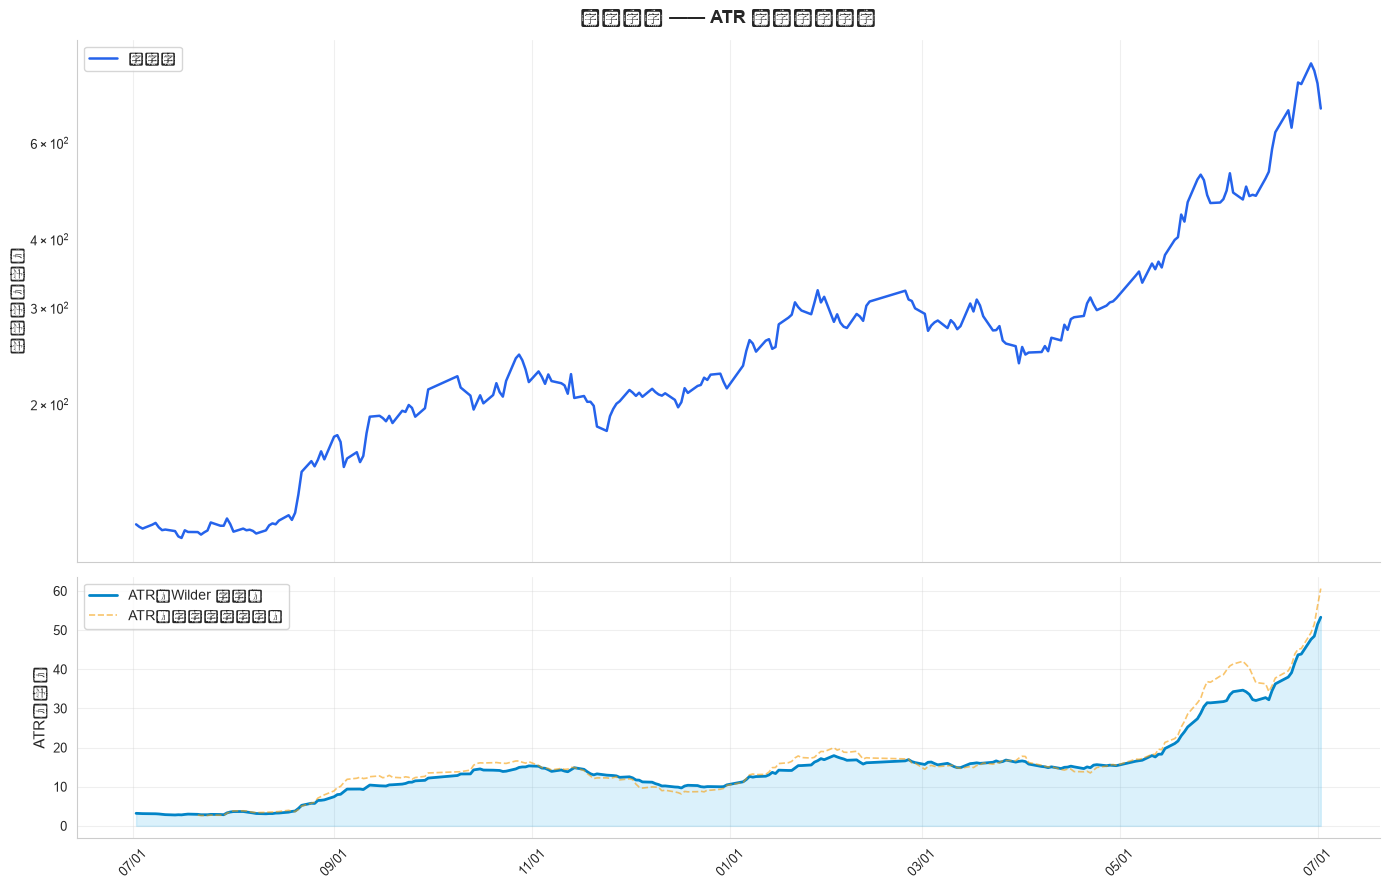

=== 用 ATR 设置止损距（示例） ===
最新收盘价：694.81 元
最新 ATR：53.29 元

止损距建议（多头）：
  1×ATR = 53.29 元，止损价 = 641.52 元（跌幅 7.7%）
  1.5×ATR = 79.94 元，止损价 = 614.87 元（跌幅 11.5%）
  2×ATR = 106.58 元，止损价 = 588.23 元（跌幅 15.3%）

止损距建议（空头）：
  1×ATR = 53.29 元，止损价 = 748.10 元（涨幅 7.7%）
  1.5×ATR = 79.94 元，止损价 = 774.75 元（涨幅 11.5%）
  2×ATR = 106.58 元，止损价 = 801.39 元（涨幅 15.3%）


In [65]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})

# ===== 上图：收盘价（对数坐标） =====
ax1.plot(df['trade_date'], df['close'], color='#2563EB', linewidth=1.8, label='收盘价')
setup_price_axis(ax1, '兆易创新 —— ATR 平均真实波幅')
ax1.set_ylabel('收盘价（元）', fontsize=11)
ax1.legend(fontsize=10)

# ===== 下图：ATR =====
ax2.fill_between(df['trade_date'], 0, df['ATR_14'], alpha=0.15, color='#0EA5E9')
ax2.plot(df['trade_date'], df['ATR_14'], color='#0284C7', linewidth=2, label='ATR（Wilder 平滑）')
ax2.plot(df['trade_date'], df['ATR_SMA'], color='#F59E0B', linewidth=1.2, linestyle='--', alpha=0.6, label='ATR（简单移动平均）')
setup_indicator_axis(ax2, 'ATR（元）')
ax2.legend(fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ===== 止损距演示 =====
print('=== 用 ATR 设置止损距（示例） ===')
latest = df.dropna(subset=['ATR_14']).iloc[-1]
entry_price = latest['close']
atr_val = latest['ATR_14']
print(f'最新收盘价：{entry_price:.2f} 元')
print(f'最新 ATR：{atr_val:.2f} 元')
print(f'\n止损距建议（多头）：')
for mult in [1, 1.5, 2]:
    stop = entry_price - mult * atr_val
    print(f'  {mult}×ATR = {mult*atr_val:.2f} 元，止损价 = {stop:.2f} 元（跌幅 {(entry_price-stop)/entry_price*100:.1f}%）')
print(f'\n止损距建议（空头）：')
for mult in [1, 1.5, 2]:
    stop = entry_price + mult * atr_val
    print(f'  {mult}×ATR = {mult*atr_val:.2f} 元，止损价 = {stop:.2f} 元（涨幅 {(stop-entry_price)/entry_price*100:.1f}%）')

---
## 五、KDJ 随机指标

**原理**：RSI 只看收盘价，KDJ 则考虑当日收盘价在「过去 N 日最高价 ~ 最低价」范围内的相对位置，对短期波动更敏感。

**公式**：
- $lowest_{{low}} = \min(low, N)$  
- $highest_{{high}} = \max(high, N)$  
- $RSV = \frac{{close - lowest_{{low}}}}{{highest_{{high}} - lowest_{{low}}}} \times 100$  
- $K = RSV$ 的平滑（常用 3 日 EMA）  
- $D = K$ 的平滑（常用 3 日 EMA）  
- $J = 3 \times K - 2 \times D$（J 会超出 0~100 范围，更敏感）

**参数**：(9, 3, 3) —— RSV 周期 9，K 平滑 3，J 系数 3  
**信号**：  
- K 上穿 D（金叉）+ J < 20 → 强买入  
- K 下穿 D（死叉）+ J > 80 → 强卖出

### Step 1：计算 RSV

In [66]:
N_kdj = 9

# 过去 N 日最低价和最高价
df['KDJ_lowest'] = df['low'].rolling(window=N_kdj).min()
df['KDJ_highest'] = df['high'].rolling(window=N_kdj).max()

# RSV = (收盘价 - 最低价) / (最高价 - 最低价) × 100
df['RSV'] = (df['close'] - df['KDJ_lowest']) / (df['KDJ_highest'] - df['KDJ_lowest']) * 100

display(df[['trade_date', 'close', 'KDJ_lowest', 'KDJ_highest', 'RSV']].iloc[N_kdj-1:N_kdj+10])

,trade_date,close,KDJ_lowest,KDJ_highest,RSV
8,2025-07-14,117.59,117.37,123.50,3.588907
9,2025-07-15,115.00,114.00,123.50,10.526316
10,2025-07-16,114.24,114.00,123.50,2.526316
11,2025-07-17,117.99,113.82,123.50,43.078512
12,2025-07-18,117.16,113.82,123.50,34.504132
13,2025-07-21,117.11,113.82,120.99,45.885635
14,2025-07-22,115.87,113.82,120.30,31.635802
15,2025-07-23,116.99,113.82,120.30,48.919753
16,2025-07-24,117.89,113.82,120.30,62.808642
17,2025-07-25,121.94,113.82,122.00,99.266504


### Step 2：计算 K、D、J 值

In [67]:
# K = RSV 的 3 日平滑（国内软件用 EMA，com=2 等价于 span=3）
df['K'] = df['RSV'].ewm(com=2, adjust=False).mean()

# D = K 的 3 日平滑
df['D'] = df['K'].ewm(com=2, adjust=False).mean()

# J = 3K - 2D
df['J'] = 3 * df['K'] - 2 * df['D']

display(df[['trade_date', 'RSV', 'K', 'D', 'J']].iloc[N_kdj+2:N_kdj+15])

,trade_date,RSV,K,D,J
11,2025-07-17,43.078512,17.543742,8.846984,34.937256
12,2025-07-18,34.504132,23.197205,13.630391,42.330833
13,2025-07-21,45.885635,30.760015,19.340266,53.599513
14,2025-07-22,31.635802,31.051944,23.244159,46.667515
15,2025-07-23,48.919753,37.007880,27.832066,55.359510
16,2025-07-24,62.808642,45.608134,33.757422,69.309559
17,2025-07-25,99.266504,63.494257,43.669700,103.143371
18,2025-07-28,76.849642,67.946052,51.761818,100.314521
19,2025-07-29,77.088305,70.993470,58.172369,96.635673
20,2025-07-30,60.908465,67.631802,61.325513,80.244379


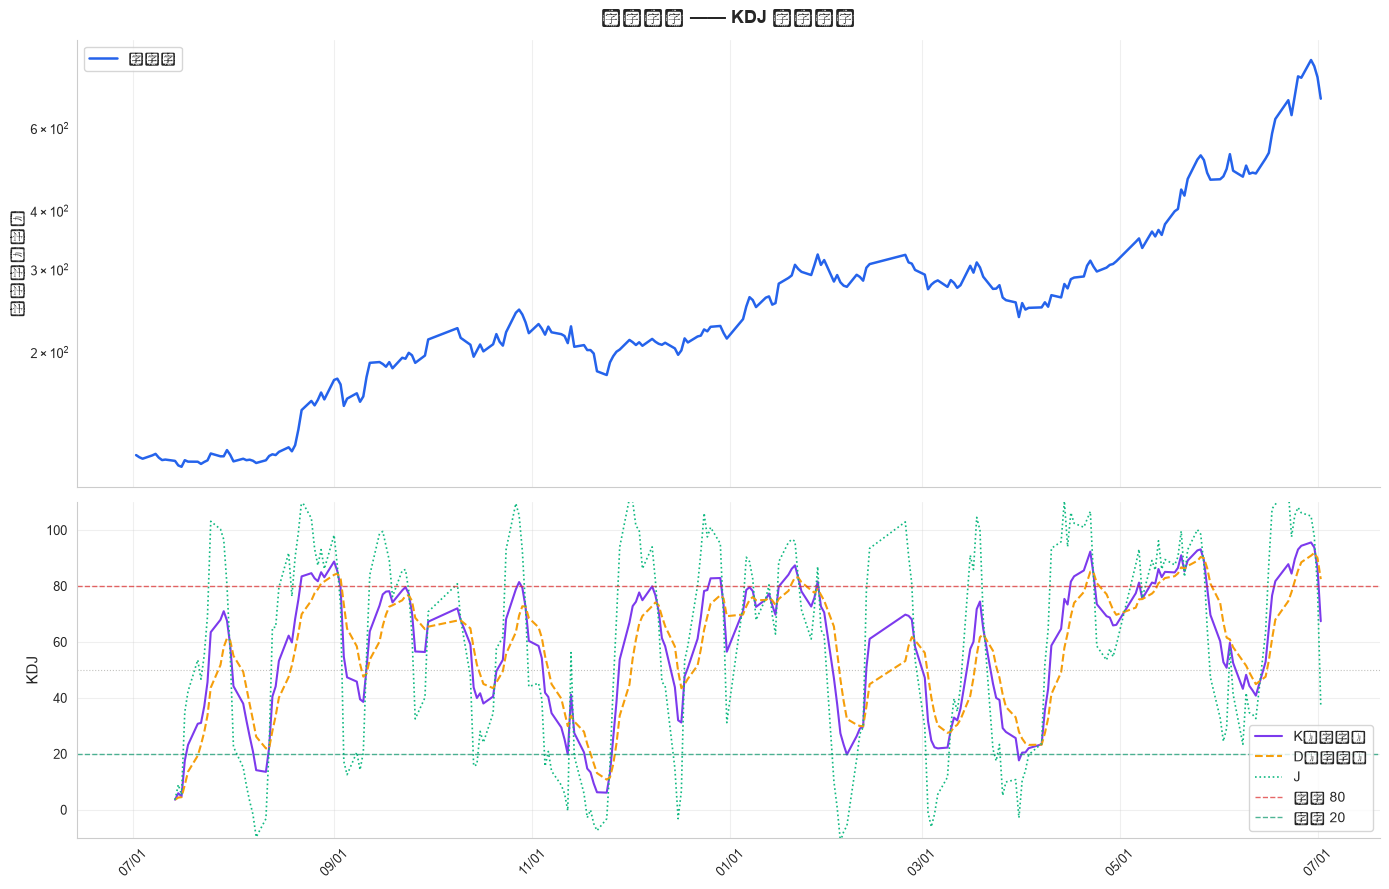

KDJ 金叉次数：17
KDJ 死叉次数：18

金叉日期（前10个）： [Timestamp('2025-08-12 00:00:00'), Timestamp('2025-09-11 00:00:00'), Timestamp('2025-09-30 00:00:00'), Timestamp('2025-10-21 00:00:00'), Timestamp('2025-11-13 00:00:00'), Timestamp('2025-11-25 00:00:00'), Timestamp('2025-12-18 00:00:00'), Timestamp('2026-01-05 00:00:00'), Timestamp('2026-01-12 00:00:00'), Timestamp('2026-01-16 00:00:00')]
死叉日期（前10个）： [Timestamp('2025-07-31 00:00:00'), Timestamp('2025-09-03 00:00:00'), Timestamp('2025-09-25 00:00:00'), Timestamp('2025-10-13 00:00:00'), Timestamp('2025-10-30 00:00:00'), Timestamp('2025-11-14 00:00:00'), Timestamp('2025-12-10 00:00:00'), Timestamp('2025-12-30 00:00:00'), Timestamp('2026-01-09 00:00:00'), Timestamp('2026-01-14 00:00:00')]


In [68]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1.5]})

# ===== 上图：价格（对数坐标） =====
ax1.plot(df['trade_date'], df['close'], color='#2563EB', linewidth=1.8, label='收盘价')
setup_price_axis(ax1, '兆易创新 —— KDJ 随机指标')
ax1.set_ylabel('收盘价（元）', fontsize=11)
ax1.legend(fontsize=10)

# ===== 下图：KDJ =====
ax2.plot(df['trade_date'], df['K'], color='#7C3AED', linewidth=1.5, label='K（快线）')
ax2.plot(df['trade_date'], df['D'], color='#F59E0B', linewidth=1.5, label='D（慢线）', linestyle='--')
ax2.plot(df['trade_date'], df['J'], color='#10B981', linewidth=1.2, label='J', linestyle=':')
ax2.axhline(80, color='#DC2626', linestyle='--', linewidth=1, alpha=0.7, label='超买 80')
ax2.axhline(20, color='#059669', linestyle='--', linewidth=1, alpha=0.7, label='超卖 20')
ax2.axhline(50, color='#888780', linestyle=':', linewidth=0.8, alpha=0.5)
setup_indicator_axis(ax2, 'KDJ')
ax2.set_ylim(-10, 110)
ax2.legend(fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 统计金叉/死叉
kdj_golden = []
kdj_death = []
for i in range(1, len(df)):
    if pd.notna(df['K'].iloc[i]) and pd.notna(df['D'].iloc[i]):
        if df['K'].iloc[i-1] < df['D'].iloc[i-1] and df['K'].iloc[i] > df['D'].iloc[i]:
            kdj_golden.append(i)
        elif df['K'].iloc[i-1] > df['D'].iloc[i-1] and df['K'].iloc[i] < df['D'].iloc[i]:
            kdj_death.append(i)

print(f'KDJ 金叉次数：{len(kdj_golden)}')
print(f'KDJ 死叉次数：{len(kdj_death)}')
print('\n金叉日期（前10个）：', [df['trade_date'].iloc[i] for i in kdj_golden[:10]])
print('死叉日期（前10个）：', [df['trade_date'].iloc[i] for i in kdj_death[:10]])

---
## 六、综合信号分析：多指标共振

将 5 个指标的信号整合，寻找「共振」日期 —— 多个指标同时发出买入或卖出信号，信号可靠性更高。

**信号定义**：

| 指标 | 买入信号 | 卖出信号 |
|------|----------|----------|
| RSI | RSI < 30 | RSI > 70 |
| MACD | DIF 上穿 DEA（金叉） | DIF 下穿 DEA（死叉） |
| 布林带 | close < 下轨（或 %B < 0） | close > 上轨（或 %B > 1） |
| ATR | ATR 处于低位（波动缩小，即将变盘）| ATR 处于高位（波动放大，风险高） |
| KDJ | K 上穿 D（金叉）且 J < 20 | K 下穿 D（死叉）且 J > 80 |

In [69]:
# 构建信号矩阵（1=买入，-1=卖出，0=无信号）
sig = df[['trade_date', 'close']].copy()

# RSI 信号
sig['RSI_buy']  = (df['RSI_14'] < 30).astype(int)
sig['RSI_sell'] = (df['RSI_14'] > 70).astype(int)

# MACD 金叉/死叉信号（当日发生）
macd_golden = [False]*len(df)
macd_death  = [False]*len(df)
for i in range(1, len(df)):
    if pd.notna(df['DIF'].iloc[i]) and pd.notna(df['DEA'].iloc[i]):
        if df['DIF'].iloc[i-1] < df['DEA'].iloc[i-1] and df['DIF'].iloc[i] > df['DEA'].iloc[i]:
            macd_golden[i] = True
        elif df['DIF'].iloc[i-1] > df['DEA'].iloc[i-1] and df['DIF'].iloc[i] < df['DEA'].iloc[i]:
            macd_death[i] = True
sig['MACD_buy']  = [int(x) for x in macd_golden]
sig['MACD_sell'] = [int(x) for x in macd_death]

# 布林带信号
sig['BB_buy']  = (df['close'] <= df['BB_lower']).astype(int)
sig['BB_sell'] = (df['close'] >= df['BB_upper']).astype(int)

# ATR 信号（ATR 处于最低 20% 分位 = 低波动，即将变盘）
atr_low_thresh = df['ATR_14'].quantile(0.2)
atr_high_thresh = df['ATR_14'].quantile(0.8)
sig['ATR_buy']  = (df['ATR_14'] < atr_low_thresh).astype(int)   # 低波动 → 买入（变盘在即）
sig['ATR_sell'] = (df['ATR_14'] > atr_high_thresh).astype(int)  # 高波动 → 卖出（风险高）
print(f'ATR 低位阈值（20%分位）：{atr_low_thresh:.2f}')
print(f'ATR 高位阈值（80%分位）：{atr_high_thresh:.2f}')

# KDJ 金叉/死叉信号
kdj_golden = [False]*len(df)
kdj_death  = [False]*len(df)
for i in range(1, len(df)):
    if pd.notna(df['K'].iloc[i]) and pd.notna(df['D'].iloc[i]):
        if df['K'].iloc[i-1] < df['D'].iloc[i-1] and df['K'].iloc[i] > df['D'].iloc[i]:
            kdj_golden[i] = True
        elif df['K'].iloc[i-1] > df['D'].iloc[i-1] and df['K'].iloc[i] < df['D'].iloc[i]:
            kdj_death[i] = True
sig['KDJ_buy']  = [int(x) for x in kdj_golden]
sig['KDJ_sell'] = [int(x) for x in kdj_death]

display(sig.head(30))

ATR 低位阈值（20%分位）：9.40
ATR 高位阈值（80%分位）：16.71


,trade_date,close,RSI_buy,RSI_sell,MACD_buy,MACD_sell,BB_buy,BB_sell,ATR_buy,ATR_sell,KDJ_buy,KDJ_sell
0,2025-07-02,120.98,0,0,0,0,0,0,1,0,0,0
1,2025-07-03,119.72,1,0,0,0,0,0,1,0,0,0
2,2025-07-04,118.85,1,0,0,0,0,0,1,0,0,0
3,2025-07-07,120.81,0,0,0,0,0,0,1,0,0,0
4,2025-07-08,121.71,0,0,0,0,0,0,1,0,0,0
5,2025-07-09,119.47,0,0,0,0,0,0,1,0,0,0
6,2025-07-10,118.06,0,0,0,0,0,0,1,0,0,0
7,2025-07-11,118.36,0,0,0,0,0,0,1,0,0,0
8,2025-07-14,117.59,0,0,0,0,0,0,1,0,0,0
9,2025-07-15,115.00,1,0,0,0,0,0,1,0,0,0


In [70]:
# 统计共振日期
sig['buy_score']  = sig['RSI_buy'] + sig['MACD_buy'] + sig['BB_buy'] + sig['ATR_buy'] + sig['KDJ_buy']
sig['sell_score'] = sig['RSI_sell'] + sig['MACD_sell'] + sig['BB_sell'] + sig['ATR_sell'] + sig['KDJ_sell']

print('=== 买入共振（至少 2 个指标同时发出买入信号） ===')
buy_resonance = sig[sig['buy_score'] >= 2][['trade_date', 'close', 'buy_score', 'RSI_buy', 'MACD_buy', 'BB_buy', 'ATR_buy', 'KDJ_buy']]
print(f'共振日期数：{len(buy_resonance)}')
if len(buy_resonance) > 0:
    display(buy_resonance)
else:
    print('（无共振日期）')

print('\n=== 卖出共振（至少 2 个指标同时发出卖出信号） ===')
sell_resonance = sig[sig['sell_score'] >= 2][['trade_date', 'close', 'sell_score', 'RSI_sell', 'MACD_sell', 'BB_sell', 'ATR_sell', 'KDJ_sell']]
print(f'共振日期数：{len(sell_resonance)}')
if len(sell_resonance) > 0:
    display(sell_resonance)
else:
    print('（无共振日期）')

=== 买入共振（至少 2 个指标同时发出买入信号） ===
共振日期数：9


,trade_date,close,buy_score,RSI_buy,MACD_buy,BB_buy,ATR_buy,KDJ_buy
1,2025-07-03,119.72,2,1,0,0,1,0
2,2025-07-04,118.85,2,1,0,0,1,0
9,2025-07-15,115.00,2,1,0,0,1,0
10,2025-07-16,114.24,2,1,0,0,1,0
17,2025-07-25,121.94,2,0,1,0,1,0
29,2025-08-12,120.47,3,0,1,0,1,1
51,2025-09-11,177.42,2,0,1,0,0,1
64,2025-09-30,213.30,2,0,1,0,0,1
115,2025-12-18,214.45,2,0,1,0,0,1



=== 卖出共振（至少 2 个指标同时发出卖出信号） ===
共振日期数：37


,trade_date,close,sell_score,RSI_sell,MACD_sell,BB_sell,ATR_sell,KDJ_sell
36,2025-08-21,137.16,2,1,0,1,0,0
37,2025-08-22,150.88,2,1,0,1,0,0
38,2025-08-25,157.80,2,1,0,1,0,0
39,2025-08-26,154.40,2,1,0,1,0,0
40,2025-08-27,158.63,2,1,0,1,0,0
41,2025-08-28,164.45,2,1,0,1,0,0
43,2025-09-01,174.88,2,1,0,1,0,0
45,2025-09-03,171.09,2,1,0,0,0,1
65,2025-10-09,225.49,2,1,0,1,0,0
127,2026-01-07,262.50,2,1,0,1,0,0


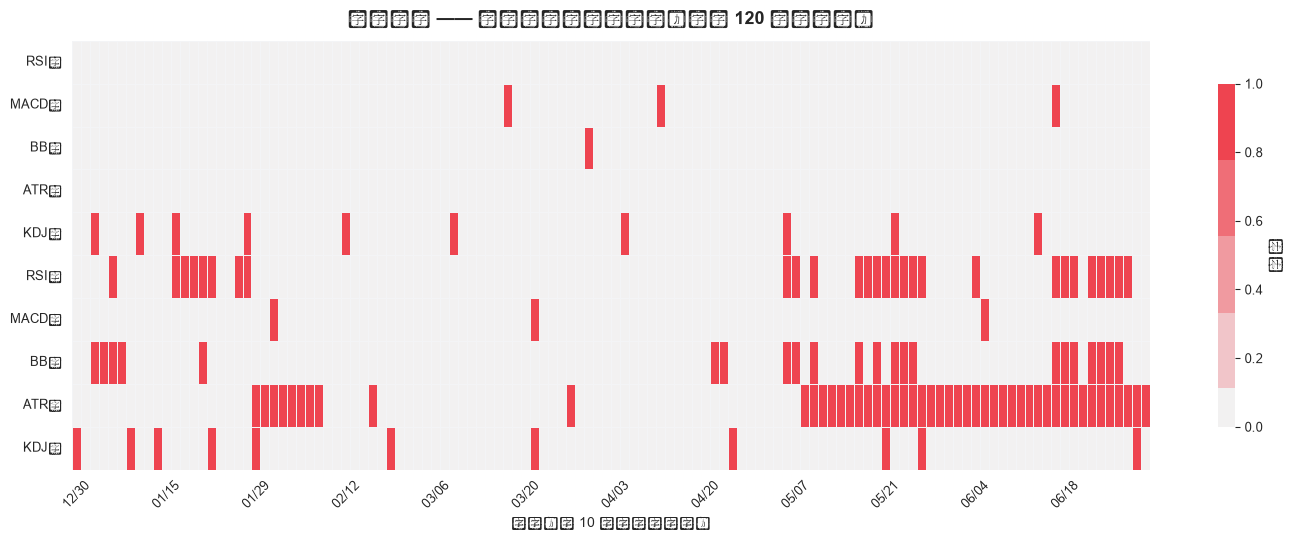

热力图说明：
  绿色格子 = 该指标当日发出买入信号
  红色格子 = 该指标当日发出卖出信号
  白色格子 = 无信号
  同一列多个绿色/红色 = 多指标共振，信号更可靠


In [71]:
import seaborn as sns

# 构建热力图数据（最近 120 个交易日）
n_days = min(120, len(sig))
idx_start = max(0, len(sig) - n_days)
heat_data = sig[['RSI_buy', 'MACD_buy', 'BB_buy', 'ATR_buy', 'KDJ_buy',
                    'RSI_sell', 'MACD_sell', 'BB_sell', 'ATR_sell', 'KDJ_sell']].tail(n_days).T

# 生成日期标签
date_labels = sig['trade_date'].iloc[idx_start:].dt.strftime('%m/%d').tolist()

fig, ax = plt.subplots(figsize=(max(14, n_days * 0.12), 5.5))
sns.heatmap(heat_data,
            cmap=sns.diverging_palette(150, 10, s=80, l=55, n=9),
            center=0,
            xticklabels=[d if i % 10 == 0 else '' for i, d in enumerate(date_labels)],
            yticklabels=['RSI买', 'MACD买', 'BB买', 'ATR买', 'KDJ买',
                        'RSI卖', 'MACD卖', 'BB卖', 'ATR卖', 'KDJ卖'],
            cbar_kws={'label': '信号', 'shrink': 0.8},
            linewidths=0.5, linecolor='#F3F4F6',
            ax=ax)
ax.set_title('兆易创新 —— 技术指标信号热力图（最近 {} 个交易日）'.format(n_days),
             fontsize=13, fontweight='600', pad=12)
ax.set_xlabel('日期（每 10 个交易日标注）', fontsize=10)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('热力图说明：')
print('  绿色格子 = 该指标当日发出买入信号')
print('  红色格子 = 该指标当日发出卖出信号')
print('  白色格子 = 无信号')
print('  同一列多个绿色/红色 = 多指标共振，信号更可靠')

---
## 总结与反思

### 已完成的指标

| 指标 | 手动实现 | 核心发现 |
|------|----------|----------|
| RSI  | ✅ | 超买/超卖阈值 70/30 |
| MACD | ✅ | DIF/DEA 金叉死叉 |
| 布林带 | ✅ | 上下轨通道 + 带宽挤压 |
| ATR  | ✅ | 波动大小，用于止损设置 |
| KDJ  | ✅ | K/D 金叉死叉，J 线更敏感 |

### 局限性说明

1. **所有技术指标都是滞后指标**，基于历史价格计算，无法预测未来。  
2. **震荡市中假信号多**（尤其是 KDJ），需结合趋势判断。  
3. **布林带挤压后方向不确定**，需配合其他指标确认。  
4. **ATR 只衡量波动，不指示方向**，需结合价格趋势使用。  
5. **综合信号共振也不是 100% 准确**，仅提高胜率，不构成投资建议。  

> ⚠️ **免责声明**：本 Notebook 仅供学习和研究使用，不构成任何投资建议。股市有风险，投资需谨慎。

### 下一步可以做什么？

- 加入**成交量指标**（OBV、VPT）验证价格走势  
- 回测**买卖信号的历史胜率**  
- 尝试**不同参数**（如 RSI 用 7 日或 21 日）  
- 加入**基本面数据**（PE、PB、营收增速）做多因子分析